# Task 3: Clustering Analysis

**Index:**
1. Load Engineered Data
2. K-Means Clustering
3. Hierarchical Clustering
4. Gaussian Mixture Models (GMM)

In [1]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import clustering utilities
from src.clustering import (
    evaluate_clustering,
    plot_cluster_scatter,
    plot_algorithm_comparison,
    compare_clusters_to_classes,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Ensure plots directory exists
os.makedirs(os.path.join(project_root, "data", "plots"), exist_ok=True)

## 1. Load Engineered Data

In [2]:
# Load engineered train/val/test data and concatenate to full dataset
features_train = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_train.csv'))
targets_train = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_train.csv')).iloc[:, 0]

features_val = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_val.csv'))
targets_val = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_val.csv')).iloc[:, 0]

features_test = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_test.csv'))
targets_test = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_test.csv')).iloc[:, 0]

# Concatenate to full dataset
X = pd.concat([features_train, features_val, features_test], axis=0, ignore_index=True)
y = pd.concat([targets_train, targets_val, targets_test], axis=0, ignore_index=True)

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index().to_string())

Features shape: (4424, 40)
Target distribution:
Target
0    1421
1     794
2    2209


In [3]:
# Compute 2D t-SNE for visualization 
from src.visualization import (
    compute_tsne,
    plot_tsne_2d,
    plot_tsne_2d_multi
)

perp = 30
tsne_embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
print(tsne_embedding.shape)

t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
(4424, 2)


Three clustering algorithms with distinct assumptions are selected:

1. **K-Means**
2. **Agglomerative Hierarchical**
3. **GMM**

## 2.0 t-SNE scatter colored by true class

t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)


Plot saved to E:\Project\2011machine_learning\data\plots\03_tsne_perp_30.png


<Axes: title={'center': 't-SNE Projection (p=30)'}, xlabel='Dimension 1', ylabel='Dimension 2'>

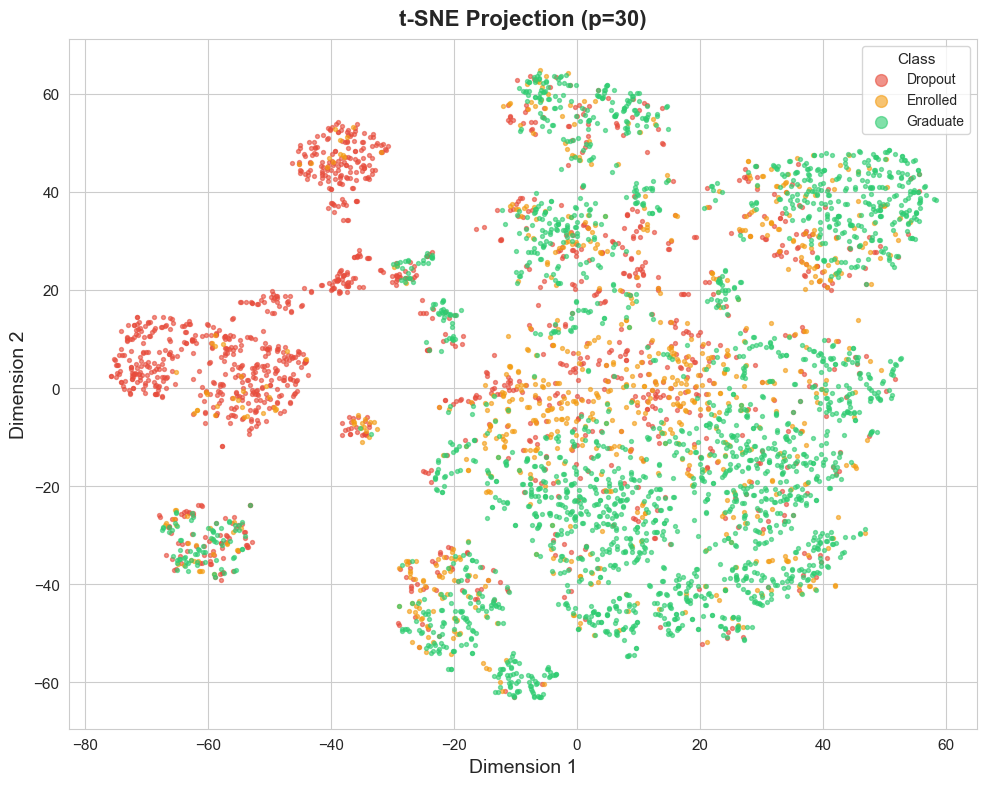

In [4]:
embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
plot_tsne_2d(
	embedding, 
	labels=y, 
	save_path=os.path.join(project_root, "data", "plots", f"03_tsne_perp_{perp}.png")
)

## 2.1 K-Means K-Value Exploration

We explore larger K values (K=3,4,5,6) to determine whether splitting classes into more clusters improves alignment with true labels. While K=3 matches the number of target classes, the target-encoded features may benefit from additional cluster granularity.

In [5]:
# K-Means K-Value Exploration
from sklearn.cluster import KMeans

print("K-Means K-Value Exploration:")
print(f"{'K':>3} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

kmeans_results = {}
for k in range(3,20):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    kmeans_results[k] = {"labels": labels, "metrics": metrics}
    print(f"{k:>3} | {metrics.get('adjusted_rand_index', 0):>8.4f} | {metrics.get('normalized_mutual_info', 0):>8.4f} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>10.2f} | {metrics.get('davies_bouldin', 0):>10.4f}")

K-Means K-Value Exploration:
  K |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------


  3 |   0.1708 |   0.1757 |     0.2741 |     839.73 |     1.5640


  4 |   0.3129 |   0.2299 |     0.1704 |     719.87 |     2.0741


  5 |   0.3052 |   0.2213 |     0.1690 |     625.90 |     1.9093


  6 |   0.2061 |   0.1861 |     0.1243 |     566.57 |     1.9614


...

 15 |   0.0742 |   0.1578 |     0.1013 |     354.35 |     2.0689


 16 |   0.0743 |   0.1584 |     0.1019 |     343.02 |     2.0755


 17 |   0.0618 |   0.1560 |     0.0985 |     323.72 |     2.0391


 18 |   0.0665 |   0.1545 |     0.1007 |     314.79 |     2.1126


 19 |   0.0579 |   0.1526 |     0.1006 |     305.62 |     2.0274


## 2.2 K-Means Detailed Analysis

K-Means (K=4) Metrics:
  silhouette: 0.1704
  silhouette_std: 0.1218
  calinski_harabasz: 719.8671
  davies_bouldin: 2.0741
  noise_ratio: 0.0000
  adjusted_rand_index: 0.3129
  normalized_mutual_info: 0.2299

K-Means Cluster Size Distribution:
 Cluster  Count  Percentage
       0   2372        53.6
       1   1074        24.3
       2    258         5.8
       3    720        16.3

K-Means Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           225  340  1807
1           565  355   154
2            53   33   172
3           578   66    76

Dominant Class per Cluster:
  Cluster 0: Graduate (76.2%)
  Cluster 1: Dropout (52.6%)
  Cluster 2: Graduate (66.7%)
  Cluster 3: Dropout (80.3%)


Plot saved to E:\Project\2011machine_learning\data\plots\03_kmeans_clusters_tsne.png


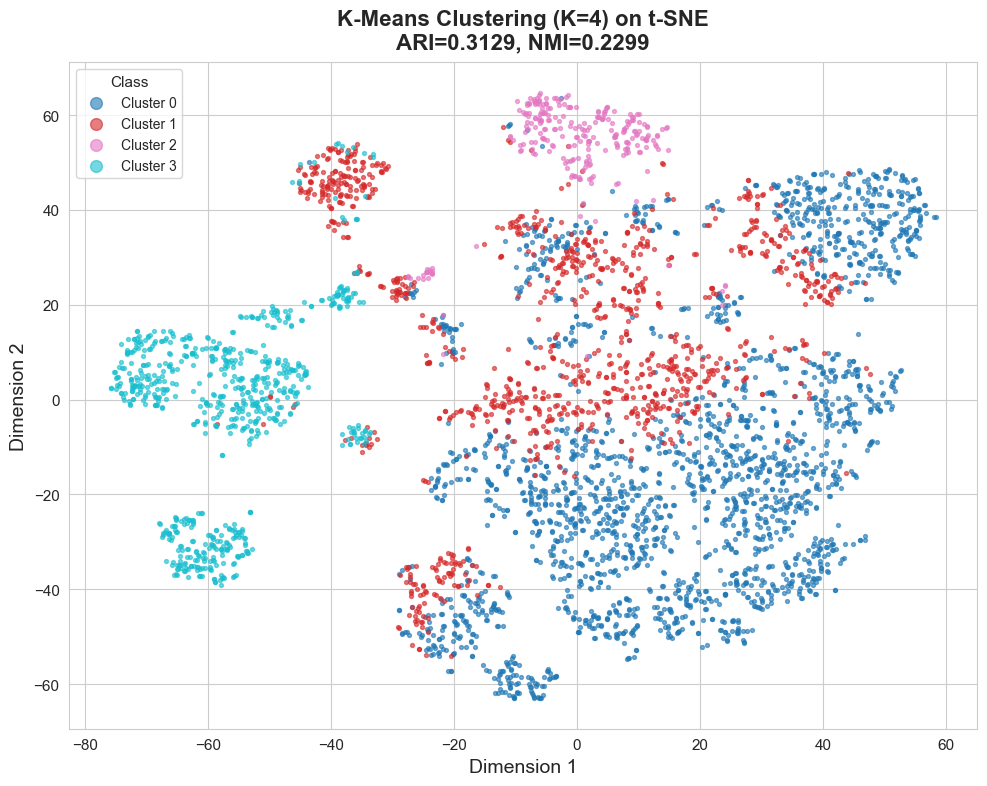

In [6]:
# K-Means Detailed Analysis (t-SNE visualization)

best_k = 4
kmeans_labels = kmeans_results[best_k]["labels"]
kmeans_metrics = kmeans_results[best_k]["metrics"]

# Update optimal_k for later comparison section
optimal_k = best_k

print(f"K-Means (K={best_k}) Metrics:")
for name, value in kmeans_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# K-Means K=4 cluster size distribution
kmeans4_cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
kmeans4_size_df = pd.DataFrame({
    "Cluster": kmeans4_cluster_sizes.index,
    "Count": kmeans4_cluster_sizes.values,
    "Percentage": (kmeans4_cluster_sizes.values / len(kmeans_labels) * 100).round(1)
})
print("\nK-Means Cluster Size Distribution:")
print(kmeans4_size_df.to_string(index=False))

# K-Means K=4 cross-tabulation
class_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
kmeans4_crosstab = compare_clusters_to_classes(kmeans_labels, y.values)
print("\nK-Means Clusters vs True Classes:")
print(kmeans4_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in kmeans4_crosstab.index:
    row = kmeans4_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

# t-SNE visualization for K-Means K=4 clusters
from src.visualization import compute_tsne, plot_tsne_2d

# Plot t-SNE with cluster labels
save_path = os.path.join(project_root, "data", "plots", "03_kmeans_clusters_tsne.png")
ax = plot_tsne_2d_multi(
    tsne_embedding, kmeans_labels,
    title=f"K-Means Clustering (K={best_k}) on t-SNE\nARI={kmeans_metrics['adjusted_rand_index']:.4f}, NMI={kmeans_metrics['normalized_mutual_info']:.4f}",
    save_path=save_path
)
plt.show()

## 3.1 Hierarchical Linkage Method and K-Value Exploration

We first compare different linkage methods (ward, complete, average, single) with K=3 to select the best one.

We then explore different K values (K=3,4,5,6) for Hierarchical Clustering with Ward linkage.

In [7]:
# Hierarchical Linkage Comparison (K=3)
from sklearn.cluster import AgglomerativeClustering

print("Hierarchical Linkage Comparison (K=3):")
print(f"{'Method':>12} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

linkage_results = {}
best_linkage = None
best_linkage_ari = 0

for method in ['ward', 'complete', 'average', 'single']:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    linkage_results[method] = {"labels": labels, "metrics": metrics}
    ari = metrics.get('adjusted_rand_index', 0)
    nmi = metrics.get('normalized_mutual_info', 0)
    sil = metrics.get('silhouette', 0)
    ch = metrics.get('calinski_harabasz', 0)
    db = metrics.get('davies_bouldin', 0)
    print(f"{method:>12} | {ari:>8.4f} | {nmi:>8.4f} | {sil:>10.4f} | {ch:>10.2f} | {db:>10.4f}")
    if ari > best_linkage_ari:
        best_linkage_ari = ari
        best_linkage = method

print(f"\nBest linkage: {best_linkage} (ARI={best_linkage_ari:.4f})")

Hierarchical Linkage Comparison (K=3):
      Method |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------


        ward |   0.1750 |   0.1609 |     0.2436 |     725.18 |     1.7059


    complete |  -0.0095 |   0.0042 |     0.2256 |     214.30 |     1.6389


     average |   0.0009 |   0.0022 |     0.5374 |      22.10 |     0.7102


      single |   0.0002 |   0.0010 |     0.5290 |       7.49 |     0.3460

Best linkage: ward (ARI=0.1750)


In [8]:
# Hierarchical Clustering K-Value Exploration (using best linkage: ward)
print(f"Hierarchical Clustering K-Value Exploration (linkage={best_linkage}):")
print(f"{'K':>3} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

hierarchical_results = {}
for k in [3, 4, 5, 6]:
    agg = AgglomerativeClustering(n_clusters=k, linkage=best_linkage)
    labels = agg.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    hierarchical_results[k] = {"labels": labels, "metrics": metrics}
    print(f"{k:>3} | {metrics.get('adjusted_rand_index', 0):>8.4f} | {metrics.get('normalized_mutual_info', 0):>8.4f} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>10.2f} | {metrics.get('davies_bouldin', 0):>10.4f}")

best_hier_k = 3  # K=3 has best ARI among hierarchical results
print(f"\nBest K for Hierarchical: {best_hier_k} (ARI={hierarchical_results[best_hier_k]['metrics']['adjusted_rand_index']:.4f})")

Hierarchical Clustering K-Value Exploration (linkage=ward):
  K |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------


  3 |   0.1750 |   0.1609 |     0.2436 |     725.18 |     1.7059


  4 |   0.1522 |   0.1501 |     0.2575 |     632.87 |     1.8877


  5 |   0.1485 |   0.1550 |     0.2480 |     550.63 |     1.5621


  6 |   0.1898 |   0.1534 |     0.1516 |     500.74 |     2.1736

Best K for Hierarchical: 3 (ARI=0.1750)


Hierarchical Clustering (ward, K=4) Metrics:
  silhouette: 0.2575
  silhouette_std: 0.1233
  calinski_harabasz: 632.8728
  davies_bouldin: 1.8877
  noise_ratio: 0.0000
  adjusted_rand_index: 0.1522
  normalized_mutual_info: 0.1501


Plot saved to E:\Project\2011machine_learning\data\plots\03_hierarchical_clusters_tsne.png


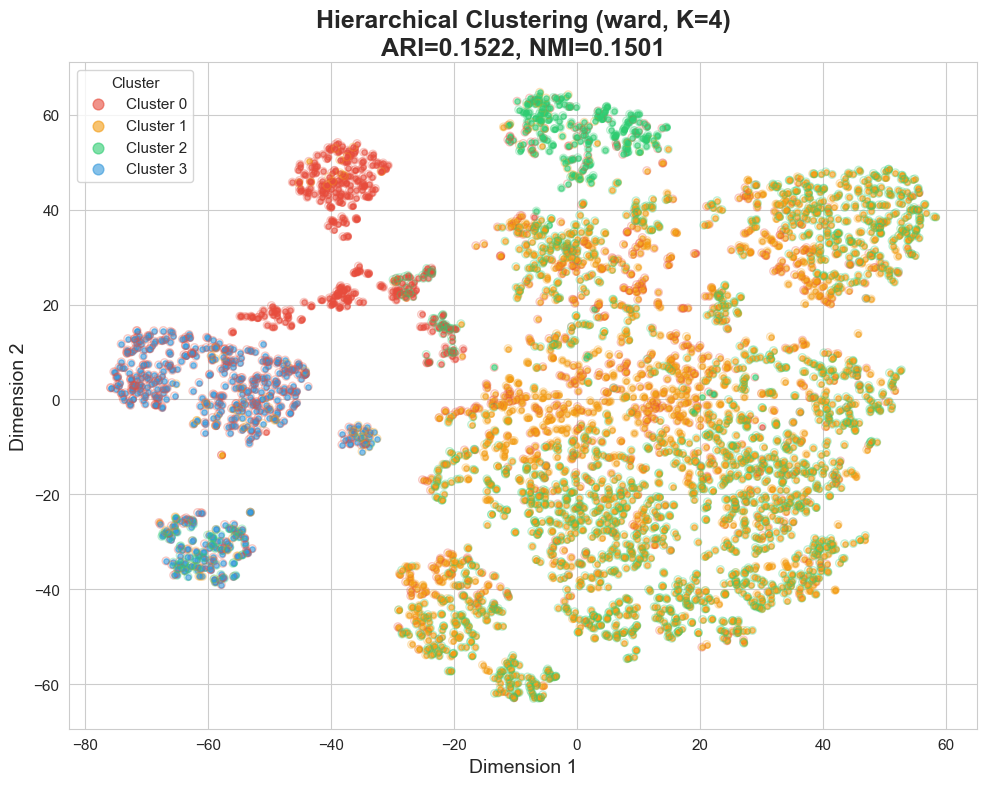

Hierarchical Cluster Size Distribution:
 Cluster  Count  Percentage
       0    382         8.6
       1   3160        71.4
       2    249         5.6
       3    633        14.3


Plot saved to E:\Project\2011machine_learning\data\plots\03_dendrogram_ward.png


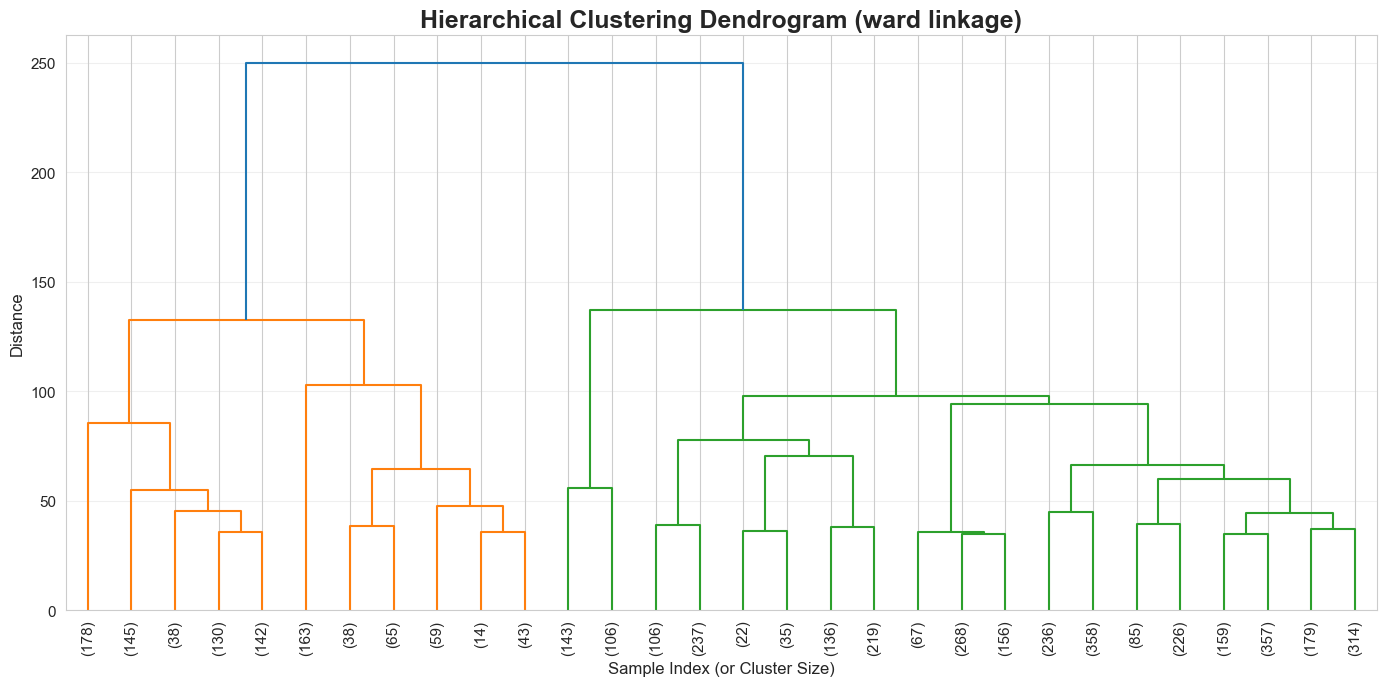


Hierarchical Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           306   16    60
1           571  668  1921
2            57   41   151
3           487   69    77

Dominant Class per Cluster:
  Cluster 0: Dropout (80.1%)
  Cluster 1: Graduate (60.8%)
  Cluster 2: Graduate (60.6%)
  Cluster 3: Dropout (76.9%)


In [9]:
# Hierarchical Clustering with best K and linkage
best_hier_k = 4
agg_labels = hierarchical_results[best_hier_k]["labels"]
agg_metrics = hierarchical_results[best_hier_k]["metrics"]

print(f"Hierarchical Clustering ({best_linkage}, K={best_hier_k}) Metrics:")
for name, value in agg_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot clusters on tsne
save_path = os.path.join(project_root, "data", "plots", "03_hierarchical_clusters_tsne.png")
ax = plot_cluster_scatter(tsne_embedding, agg_labels, title=f"Hierarchical Clustering ({best_linkage}, K={best_hier_k})\nARI={agg_metrics['adjusted_rand_index']:.4f}, NMI={agg_metrics['normalized_mutual_info']:.4f}", y_true=y.values, save_path=save_path)
plt.show()

# Hierarchical cluster size distribution table
agg_cluster_sizes = pd.Series(agg_labels).value_counts().sort_index()
agg_size_df = pd.DataFrame({
    "Cluster": agg_cluster_sizes.index,
    "Count": agg_cluster_sizes.values,
    "Percentage": (agg_cluster_sizes.values / len(y) * 100).round(1)
})
print("Hierarchical Cluster Size Distribution:")
print(agg_size_df.to_string(index=False))

# Hierarchical Clustering Dendrogram (best linkage)

from src.clustering import plot_dendrogram
fig = plot_dendrogram(
    X.values,
    method=best_linkage,
    save_path=os.path.join(project_root, "data", "plots", "03_dendrogram_ward.png"),
)
plt.show()

# Hierarchical cross-tabulation
agg_crosstab = compare_clusters_to_classes(agg_labels, y.values)
print("\nHierarchical Clusters vs True Classes:")
print(agg_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in agg_crosstab.index:
    row = agg_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

## 4.1 GMM K-Value and Covariance Exploration

We explore different K values (K=3,4,5,6) and covariance types (full, tied, diag, spherical) for GMM to find the optimal configuration.

In [10]:
# GMM K-Value and Covariance Exploration
from sklearn.mixture import GaussianMixture

print("GMM K-Value and Covariance Exploration:")
print(f"{'K':>3} | {'Cov':>10} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 75)

gmm_results = {}
best_gmm_config = None
best_gmm_ari = 0

for k in [3, 4, 5, 6]:
    for cov in ['full', 'tied', 'diag', 'spherical']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42, n_init=5)
        labels = gmm.fit_predict(X.values)
        metrics = evaluate_clustering(X.values, labels, y.values)
        gmm_results[(k, cov)] = {"labels": labels, "metrics": metrics}
        ari = metrics.get('adjusted_rand_index', 0)
        nmi = metrics.get('normalized_mutual_info', 0)
        sil = metrics.get('silhouette', 0)
        ch = metrics.get('calinski_harabasz', 0)
        db = metrics.get('davies_bouldin', 0)
        print(f"{k:>3} | {cov:>10} | {ari:>8.4f} | {nmi:>8.4f} | {sil:>10.4f} | {ch:>10.2f} | {db:>10.4f}")


GMM K-Value and Covariance Exploration:
  K |        Cov |      ARI |      NMI | Silhouette |   CH Index |   DB Index
---------------------------------------------------------------------------


  3 |       full |   0.1964 |   0.1614 |     0.1799 |     647.11 |     3.3248


  3 |       tied |   0.3324 |   0.2578 |     0.1510 |     741.35 |     2.4022


  3 |       diag |   0.3334 |   0.2505 |     0.1670 |     712.43 |     2.7407


  3 |  spherical |   0.2015 |   0.1573 |     0.1890 |     722.85 |     2.7366


...

  5 |  spherical |   0.1561 |   0.1506 |     0.0953 |     581.16 |     2.1911


  6 |       full |   0.0965 |   0.1111 |     0.0362 |     386.56 |     3.8254


  6 |       tied |   0.2392 |   0.2201 |     0.1035 |     504.07 |     2.1013


  6 |       diag |   0.1292 |   0.1842 |     0.0379 |     436.99 |     3.6555


  6 |  spherical |   0.1595 |   0.1636 |     0.1030 |     520.95 |     2.3651


GMM (K=4, covariance=tied) Metrics:
  silhouette: 0.1423
  silhouette_std: 0.1040
  calinski_harabasz: 559.9146
  davies_bouldin: 2.2580
  noise_ratio: 0.0000
  adjusted_rand_index: 0.3336
  normalized_mutual_info: 0.2734


Plot saved to E:\Project\2011machine_learning\data\plots\03_gmm_clusters_tsne.png


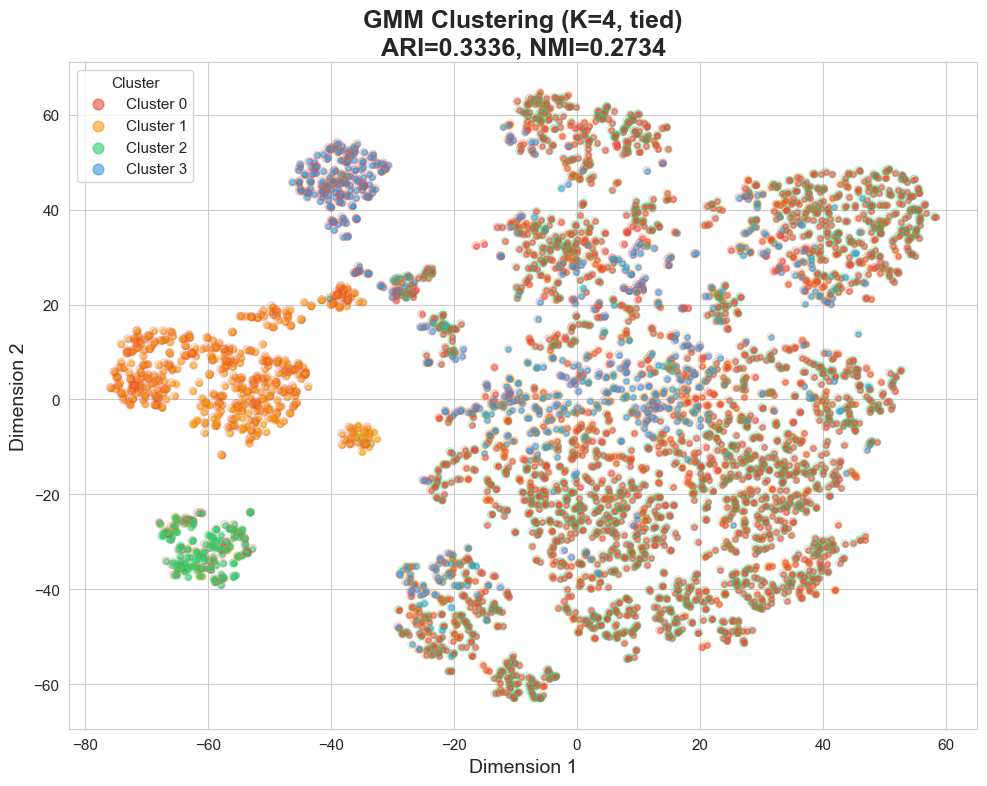


Cluster probabilities (first 5 points):
[[0.941 0.    0.    0.059]
 [1.    0.    0.    0.   ]
 [1.    0.    0.    0.   ]
 [0.147 0.    0.    0.853]
 [1.    0.    0.    0.   ]]

GMM Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           347  492  2082
1           493   43     2
2            77   28    75
3           504  231    50

Dominant Class per Cluster:
  Cluster 0: Graduate (71.3%)
  Cluster 1: Dropout (91.6%)
  Cluster 2: Dropout (42.8%)
  Cluster 3: Dropout (64.2%)


In [11]:
# GMM with best configuration (K=4, tied covariance)
gmm_labels = gmm_results[(4, 'tied')]["labels"]
gmm_metrics = gmm_results[(4, 'tied')]["metrics"]
gmm_k = 4
best_gmm_cov = 'tied'

print(f"GMM (K={gmm_k}, covariance={best_gmm_cov}) Metrics:")
for name, value in gmm_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot GMM clusters on tsne
save_path = os.path.join(project_root, "data", "plots", "03_gmm_clusters_tsne.png")
ax = plot_cluster_scatter(
    tsne_embedding, gmm_labels,
    title=f"GMM Clustering (K={gmm_k}, {best_gmm_cov})\nARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}",
    y_true=y.values, save_path=save_path
)
plt.show()

# Cluster probabilities (sample of first 5 points)
from sklearn.mixture import GaussianMixture
gmm_model = GaussianMixture(n_components=gmm_k, covariance_type=best_gmm_cov, random_state=42, n_init=5)
gmm_model.fit(X.values)
gmm_probs = gmm_model.predict_proba(X.values)
print(f"\nCluster probabilities (first 5 points):")
print(gmm_probs[:5].round(3))

# GMM cross-tabulation
gmm_crosstab = compare_clusters_to_classes(gmm_labels, y.values)
print("\nGMM Clusters vs True Classes:")
print(gmm_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in gmm_crosstab.index:
    row = gmm_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

## 5. Multi-Algorithm Comparison

We compare all three algorithms (K-Means, Hierarchical, GMM) using six evaluation metrics: Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index, Adjusted Rand Index (ARI), and Normalized Mutual Information (NMI). Silhouette, CH, and DB are unsupervised metrics that do not require ground truth labels, while ARI and NMI measure alignment with the true class assignments.

CLUSTERING ALGORITHM COMPARISON:
------------------------------------------------------------------------------------------
                     Algorithm |    K | Silhouette |     CH Index |   DB Index |      ARI |      NMI
------------------------------------------------------------------------------------------
                 K-Means (K=4) |    4 |     0.1704 |       719.87 |     2.0741 |   0.3129 |   0.2299
      Hierarchical (Ward, K=4) |    4 |     0.2575 |       632.87 |     1.8877 |   0.1522 |   0.1501
               GMM (K=4, tied) |    4 |     0.1423 |       559.91 |     2.2580 |   0.3336 |   0.2734
------------------------------------------------------------------------------------------


Plot saved to E:\Project\2011machine_learning\data\plots\03a_algorithm_comparison.png


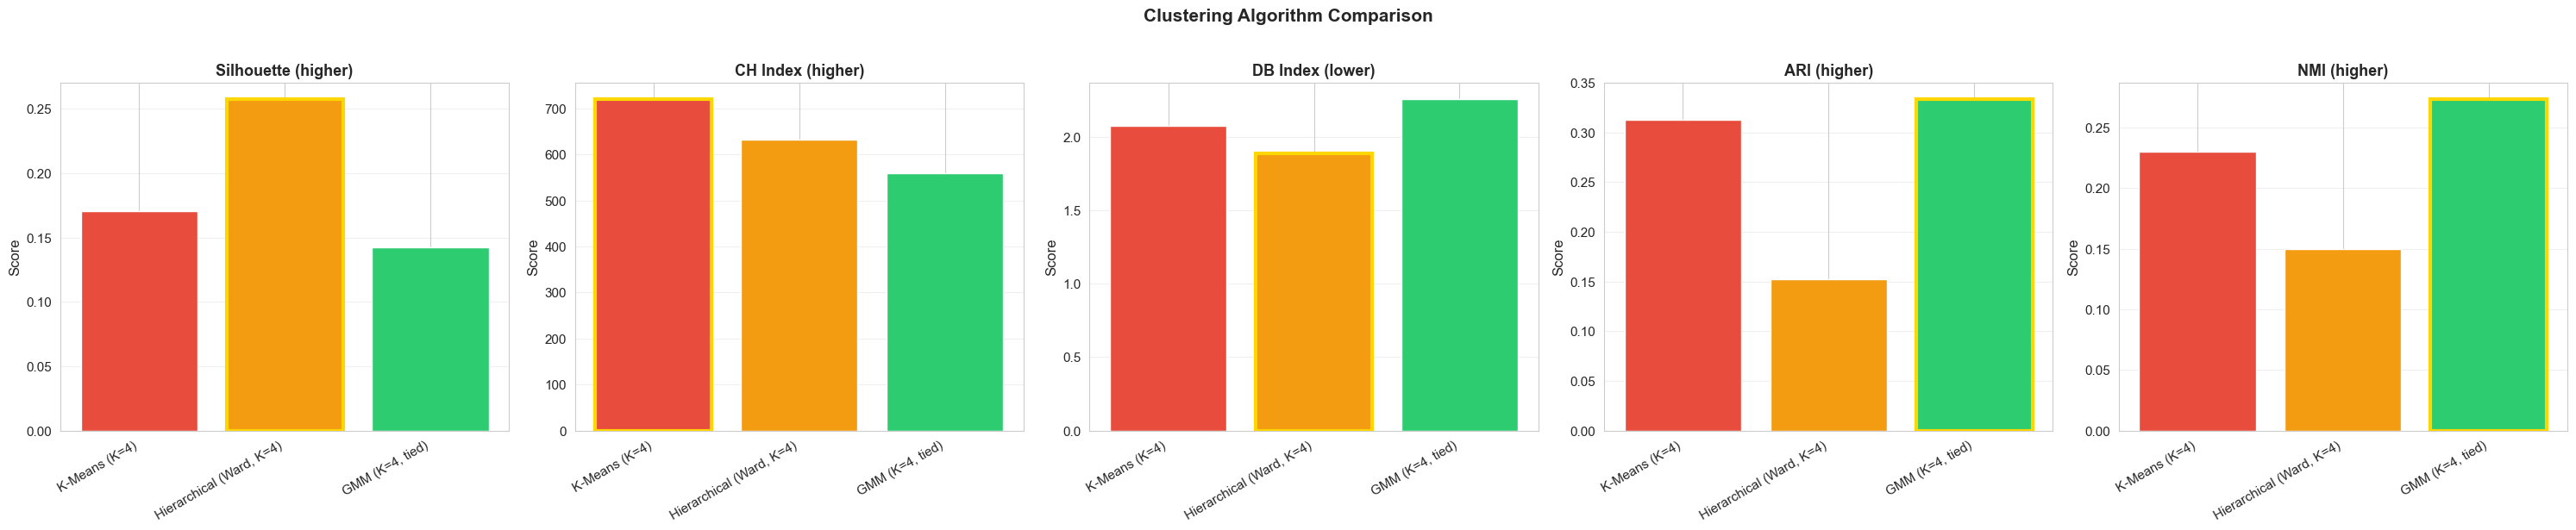

In [12]:
# Multi-algorithm comparison (using best configurations for each algorithm)
all_algorithms = {
    f"K-Means (K={optimal_k})": {"labels": kmeans_labels, "metrics": kmeans_metrics, "n_clusters": optimal_k},
    f"Hierarchical (Ward, K={best_hier_k})": {"labels": agg_labels, "metrics": agg_metrics, "n_clusters": best_hier_k},
    f"GMM (K={gmm_k}, {best_gmm_cov})": {"labels": gmm_labels, "metrics": gmm_metrics, "n_clusters": gmm_k},
}

print("CLUSTERING ALGORITHM COMPARISON:")
print("-" * 90)
print(f"{'Algorithm':>30} | {'K':>4} | {'Silhouette':>10} | {'CH Index':>12} | {'DB Index':>10} | {'ARI':>8} | {'NMI':>8}")
print("-" * 90)

for alg_name, results in all_algorithms.items():
    m = results["metrics"]
    k = results["n_clusters"]
    print(f"{alg_name:>30} | {k:>4} | {m.get('silhouette', 0):>10.4f} | {m.get('calinski_harabasz', 0):>12.2f} | {m.get('davies_bouldin', 0):>10.4f} | {m.get('adjusted_rand_index', 0):>8.4f} | {m.get('normalized_mutual_info', 0):>8.4f}")

print("-" * 90)

all_results_dict = {alg: res["metrics"] for alg, res in all_algorithms.items()}

save_path = os.path.join(project_root, "data", "plots", "03a_algorithm_comparison.png")
fig = plot_algorithm_comparison(all_results_dict, y.values, save_path=save_path)
plt.show()

## 6. Best Algorithm Analysis

In [13]:
# Best algorithm determination based on ARI and NMI
# Compare best configurations: K-Means K=4, Hierarchical K=3, GMM K=4 (tied)

print("Best algorithm comparison (ARI/NMI):")
print(f"  K-Means (K=4):                    ARI={kmeans_metrics['adjusted_rand_index']:.4f}, NMI={kmeans_metrics['normalized_mutual_info']:.4f}")
print(f"  Hierarchical (K=4):                ARI={agg_metrics['adjusted_rand_index']:.4f}, NMI={agg_metrics['normalized_mutual_info']:.4f}")
print(f"  GMM (K=4, tied covariance):       ARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}")

# Find best
all_aris = {
    f"K-Means (K={optimal_k})": kmeans_metrics['adjusted_rand_index'],
    f"Hierarchical (K={best_hier_k})": agg_metrics['adjusted_rand_index'],
    f"GMM (K={gmm_k}, {best_gmm_cov})": gmm_metrics['adjusted_rand_index'],
}
best_algorithm = max(all_aris, key=all_aris.get)
print(f"\nBest algorithm: {best_algorithm} (ARI={all_aris[best_algorithm]:.4f})")

# Get best labels
if "K-Means" in best_algorithm:
    best_labels = kmeans_labels
elif "Hierarchical" in best_algorithm:
    best_labels = agg_labels
else:
    best_labels = gmm_labels

Best algorithm comparison (ARI/NMI):
  K-Means (K=4):                    ARI=0.3129, NMI=0.2299
  Hierarchical (K=4):                ARI=0.1522, NMI=0.1501
  GMM (K=4, tied covariance):       ARI=0.3336, NMI=0.2734

Best algorithm: GMM (K=4, tied) (ARI=0.3336)
